# Kidney cancer dataset analysis

In [35]:
import os
import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import anndata as ad

import sys
sys.path.append(r'/import/home2/share/yqzeng/MacSGP/codes/MacSGP')
from vis import plot_spatial_ct

from gaston import cluster_plotting, dp_related, model_selection
from gaston import binning_and_plotting, isodepth_scaling
from gaston import process_NN_output

In [2]:
import matplotlib as mpl
from matplotlib import cm
mpl.rcParams.update({
    "pdf.fonttype": 42,       
    "ps.fonttype": 42,
    "axes.linewidth": 0.8,
})

mpl.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.edgecolor": "#333333",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

In [3]:
DATA_PATH = "/home/yzengbj/my_project/data/kidney_cancer"
EXPORT_PATH = "/home/yzengbj/factor/data/kidney_cancer"
SAVE_PATH = "/home/yzengbj/factor/results/kidney_cancer"
FIG_PATH = "/home/yzengbj/factor/experiments/kidney_cancer/fig"

In [4]:
adata_result = ad.read_h5ad(os.path.join(SAVE_PATH, "adata_result_inter.h5ad"))
adata_ref = ad.read_h5ad(os.path.join(EXPORT_PATH, "adata_basis_inter.h5ad"))

## Results of RCC

Dropping cell types: []


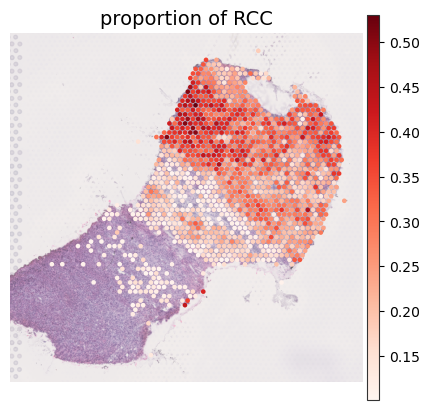

In [46]:
plot_spatial_ct(adata_result, index='proportion', celltype_plot=['RCC'],
                proportion_threshold=0.1, num_threshold=100, 
                cmap='Reds', 
                spot_size=100, 
                ncols=6)

Dropping cell types: []


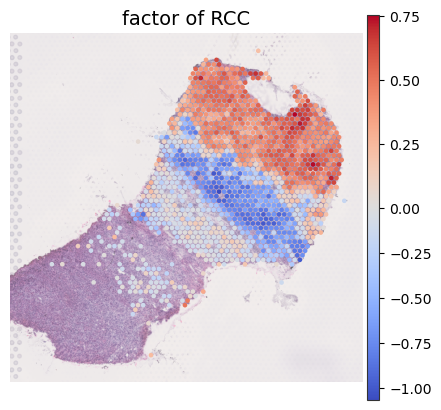

In [44]:
plot_spatial_ct(adata_result, index='factor', celltype_plot=['RCC'],
                proportion_threshold=0.1, num_threshold=100, 
                cmap='coolwarm', 
                spot_size=100, 
                ncols=6)

In [9]:
counts_mat = adata_result.obsm['count']
coords_mat = adata_result.obsm['spatial']
proportion_df = adata_result.obsm['proportion']

## Spatial gradient analysis

In [5]:
gaston_model, A, S= process_NN_output.process_files(os.path.join(SAVE_PATH, 'gaston_modified')) 


best model: /home/yzengbj/factor/results/kidney_cancer/gaston_modified/seed_0


Kneedle number of domains: 4


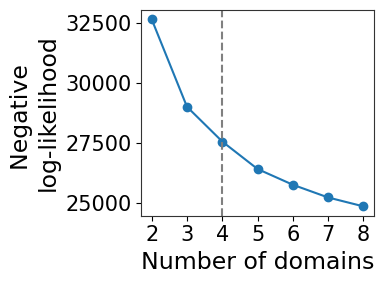

In [7]:
model_selection.plot_ll_curve(gaston_model, A, S, max_domain_num=8, start_from=2)

In [8]:
# CHANGE FOR YOUR APPLICATION: use number of domains from above!
num_layers=4

# identify labels
gaston_isodepth, gaston_labels=dp_related.get_isodepth_labels(gaston_model,A,S,num_layers)

# DATASET-SPECIFIC: so domains are ordered oligodendrocyte to molecular, with increasing isodepth
gaston_isodepth=np.max(gaston_isodepth) - gaston_isodepth
gaston_labels=(num_layers-1)-gaston_labels

In [10]:
scale_factor=0.748 # visium

# WITHOUT
gaston_isodepth=isodepth_scaling.adjust_isodepth(gaston_isodepth, gaston_labels, coords_mat, 
                                 q_vals=[0.15, 0.15, 0.15, 0.15], scale_factor=scale_factor)

In [11]:
ct = 'RCC'
extra_data = []
proportion = adata_result.obsm['proportion'][ct].values

extra_data.append(proportion)

ct = 'T-cell'
proportion = adata_result.obsm['proportion'][ct].values
extra_data.append(proportion)

ct = 'B-cell'
proportion = adata_result.obsm['proportion'][ct].values
extra_data.append(proportion)

output = binning_and_plotting.bin_data(adata_result.obsm['count'], gaston_labels, gaston_isodepth, 
                         proportion_df, adata_result.var_names, num_bins_per_domain=[10,10,10,10], extra_data=extra_data,)

In [12]:
left_bps=[]
right_bps=[]

for i in range(len(output['binned_labels'])-1):
    if output['binned_labels'][i] != output['binned_labels'][i+1]:
        left_bps.append(output['unique_binned_isodepths'][i])
        right_bps.append(output['unique_binned_isodepths'][i+1])

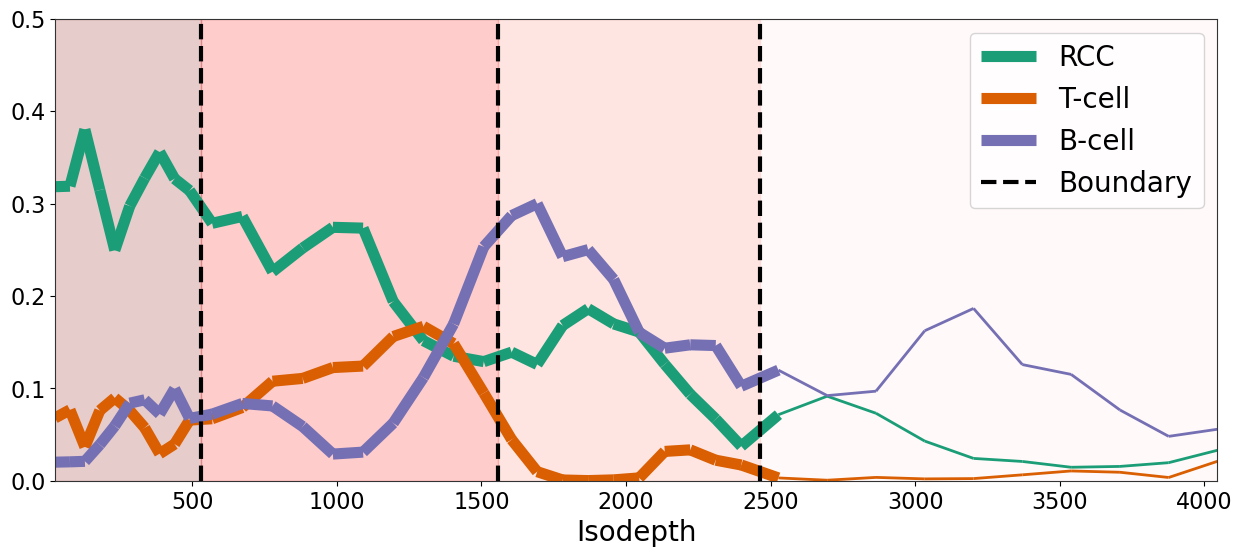

In [13]:
palette = mpl.cm.get_cmap('Dark2', 8)
layer_colors=['mistyrose', 'salmon', 'red', 'darkred']
layer_colors = layer_colors[::-1]
spot_colors = ['royalblue', 'orange', 'green', 'purple']
domain_boundary_label = [1,2,3,4]

fig,ax=plt.subplots(figsize=[15,6])
ylim = [0, 0.5]
width1=2
width2=8

widths = np.ones(len(output['unique_binned_isodepths']))*width2
widths[np.where(output['binned_labels']==3)[0]] = width1

x = output['unique_binned_isodepths']
y = output['binned_extra_data'][0]
points = np.vstack([x, y]).T.reshape(-1, 1, 2)
segments = np.hstack([points[:-1], points[1:]])
lc = LineCollection(segments, alpha=1, color=palette(0), lw=widths, label='RCC')
line = ax.add_collection(lc)

x = output['unique_binned_isodepths']
y = output['binned_extra_data'][1]
points = np.vstack([x, y]).T.reshape(-1, 1, 2)
segments = np.hstack([points[:-1], points[1:]])
lc = LineCollection(segments, alpha=1, color=palette(1), lw=widths, label='T-cell')
line = ax.add_collection(lc)

x = output['unique_binned_isodepths']
y = output['binned_extra_data'][2]
points = np.vstack([x, y]).T.reshape(-1, 1, 2)
segments = np.hstack([points[:-1], points[1:]])
lc = LineCollection(segments, alpha=1, color=palette(2), lw=widths, label='B-cell')
line = ax.add_collection(lc)

for i in range(4-1):
    if i==0:
        plt.axvline((left_bps[i]+right_bps[i])*0.5, color='black', ls='--', linewidth=3, label='Boundary')
        ax.fill_betweenx(ylim, 0, (left_bps[i]+right_bps[i])*0.5, color=layer_colors[i], alpha=0.2)
    else:
        plt.axvline((left_bps[i]+right_bps[i])*0.5, color='black', ls='--', linewidth=3)
        ax.fill_betweenx(ylim, (left_bps[i-1]+right_bps[i-1])*0.5, (left_bps[i]+right_bps[i])*0.5, color=layer_colors[i], alpha=0.2)
#plt.legend(fontsize=20)
ax.fill_betweenx(ylim, (left_bps[2]+right_bps[2])*0.5, output['unique_binned_isodepths'][-1], color=layer_colors[3], alpha=0.2)
ax.set_xlim(output['unique_binned_isodepths'][0], output['unique_binned_isodepths'][-1])
ax.set_ylim(ylim)
ax.set_xlabel('Isodepth', fontsize=20)
#ax.set_ylabel('Proportion', fontsize=20)
#ax.set_title('Proportion', fontsize=20)
# larger font size for ticks
ax.tick_params(axis='both', which='major', labelsize=16)
ax.tick_params(axis='both', which='minor', labelsize=14)
plt.legend(fontsize=20, )
#plt.savefig(os.path.join(FIG_PATH, 'kidney_cancer_celltype_proportion_vs_isodepth.pdf'), dpi=300)
plt.show()

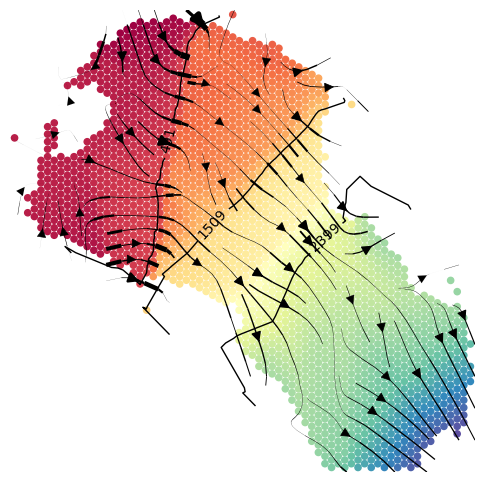

In [14]:
show_streamlines=True
cluster_plotting.plot_isodepth(gaston_isodepth, S, gaston_model, figsize=(6,6), streamlines=show_streamlines, cmap=plt.cm.Spectral, arrowsize=1.5,
                              neg_gradient=True, colorbar=False, streamlines_lw=4,contour_levels=left_bps)

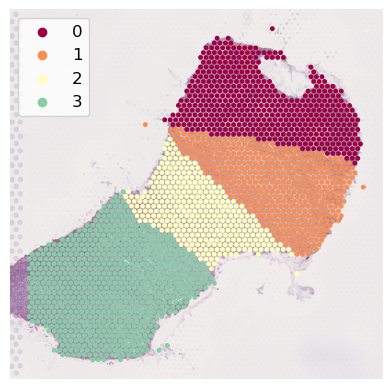

In [18]:
colors = [plt.cm.Spectral(i) for i in np.linspace(0, 0.75, num_layers)]
adata_result.obs['layer_labels'] = gaston_labels.astype(int).astype(str)

sc.pl.spatial(adata_result, color='layer_labels', 
              #palette=["#c20505", "#ff6835b9", "#eeee3c", '#7fbc41'], 
              palette=colors,
              spot_size=100, 
              alpha_img=0.7,
              legend_loc='upper left',
              title='',
              frameon=False, 
              #save=os.path.join('kidney_cancer_layer_labels.pdf')
              )

In [19]:
ct = 'RCC'

extra_data = []
metagene_1 = adata_result.var_names[adata_result.varm['loading'][ct] > 1.0]

meta_expre_1 = adata_result[:, metagene_1].X
meta_expre_1 = meta_expre_1.toarray()
meta_expre_mean_1 = meta_expre_1.mean(axis=1)

extra_data.append(meta_expre_mean_1)

output = binning_and_plotting.bin_data(adata_result.obsm['count'], gaston_labels, gaston_isodepth, 
                         proportion_df, adata_result.var_names, num_bins_per_domain=[10,10,10,10], extra_data=extra_data,)

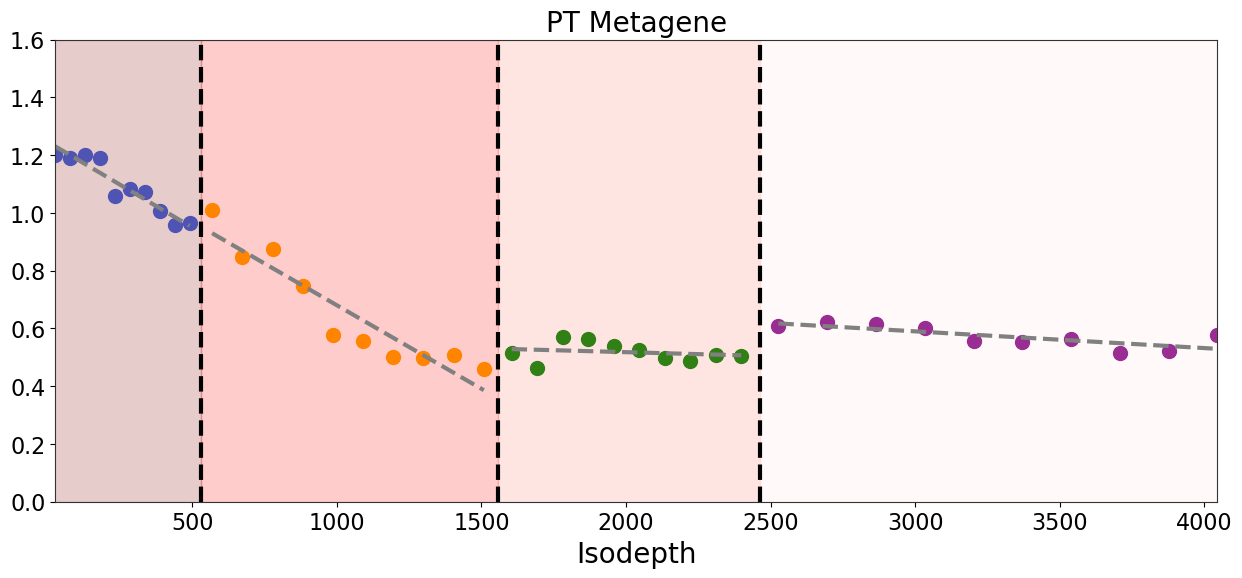

In [21]:
# plot output['binned_extra_data'][0] as 4 parts devided by the isodepth boundaries, each part fit a linear regression
fig,ax=plt.subplots(figsize=[15,6])
spot_colors = ['royalblue', 'orange', 'green', 'purple']
ylim = [0, 1.6]
for i in range(4):
    if i == 0:
        start = 0
        end = len(output['binned_extra_data'][0][output['binned_labels'] == i])
        x = output['unique_binned_isodepths'][start:end].copy()
        y = output['binned_extra_data'][0][output['binned_labels'] == i].copy()
    else:
        start = start + len(output['binned_extra_data'][0][output['binned_labels'] == i-1])
        end = start + len(output['binned_extra_data'][0][output['binned_labels'] == i])
        #print(start, end)
        x = output['unique_binned_isodepths'][start:end].copy()
        y = output['binned_extra_data'][0][output['binned_labels'] == i].copy()
    #print(x)
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.plot(x, p(x), '--', linewidth=3, color='grey', label=f'Layer {i+1}')
    plt.scatter(x, y, s=100, color=spot_colors[i], alpha=1)
layer_colors=['mistyrose', 'salmon', 'red', 'darkred']
layer_colors = layer_colors[::-1]
for i in range(4-1):
    if i==0:
        plt.axvline((left_bps[i]+right_bps[i])*0.5, color='black', ls='--', linewidth=3, label=domain_boundary_label)
        ax.fill_betweenx(ylim, 0, (left_bps[i]+right_bps[i])*0.5, color=layer_colors[i], alpha=0.2)
    else:
        plt.axvline((left_bps[i]+right_bps[i])*0.5, color='black', ls='--', linewidth=3)
        ax.fill_betweenx(ylim, (left_bps[i-1]+right_bps[i-1])*0.5, (left_bps[i]+right_bps[i])*0.5, color=layer_colors[i], alpha=0.2)
#plt.legend(fontsize=20)
ax.fill_betweenx(ylim, (left_bps[2]+right_bps[2])*0.5, output['unique_binned_isodepths'][-1], color=layer_colors[3], alpha=0.2)
ax.set_xlim(output['unique_binned_isodepths'][0], output['unique_binned_isodepths'][-1])
ax.set_ylim(ylim)
ax.set_xlabel('Isodepth', fontsize=20)
#ax.set_ylabel('Relative expression', fontsize=20)
ax.set_title('PT Metagene', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.tick_params(axis='both', which='minor', labelsize=14)
#plt.legend(fontsize=20, )
#plt.savefig(os.path.join(FIG_PATH, 'kidney_cancer_RCC_metagene1_vs_isodepth.pdf'), dpi=300)
plt.show()

In [30]:
ct = 'RCC'

extra_data = []
metagene_2 = adata_result.var_names[adata_result.varm['loading'][ct] < -1.0]

meta_expre_2 = adata_result[:, metagene_2].X
meta_expre_2 = meta_expre_2.toarray()
meta_expre_mean_2 = meta_expre_2.mean(axis=1)

extra_data.append(meta_expre_mean_2)

output = binning_and_plotting.bin_data(adata_result.obsm['count'], gaston_labels, gaston_isodepth, 
                         proportion_df, adata_result.var_names, num_bins_per_domain=[10,10,10,10], extra_data=extra_data,)

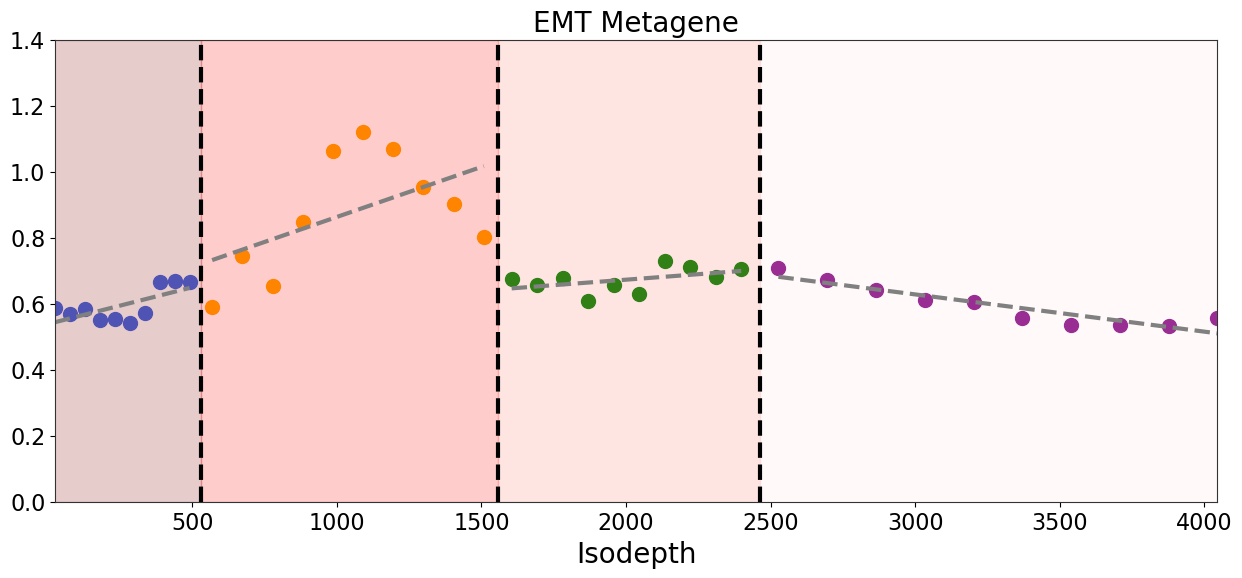

In [31]:
fig,ax=plt.subplots(figsize=[15,6])
spot_colors = ['royalblue', 'orange', 'green', 'purple']
ylim = [0, 1.4]
for i in range(4):
    if i == 0:
        start = 0
        end = len(output['binned_extra_data'][0][output['binned_labels'] == i])
        x = output['unique_binned_isodepths'][start:end].copy()
        y = output['binned_extra_data'][0][output['binned_labels'] == i].copy()
    else:
        start = start + len(output['binned_extra_data'][0][output['binned_labels'] == i-1])
        end = start + len(output['binned_extra_data'][0][output['binned_labels'] == i])
        #print(start, end)
        x = output['unique_binned_isodepths'][start:end].copy()
        y = output['binned_extra_data'][0][output['binned_labels'] == i].copy()
    #print(x)
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.plot(x, p(x), '--', linewidth=3, color='grey', label=f'Layer {i+1}')
    plt.scatter(x, y, s=100, color=spot_colors[i], alpha=1)
layer_colors=['mistyrose', 'salmon', 'red', 'darkred']
layer_colors = layer_colors[::-1]
for i in range(4-1):
    if i==0:
        plt.axvline((left_bps[i]+right_bps[i])*0.5, color='black', ls='--', linewidth=3, label=domain_boundary_label)
        ax.fill_betweenx(ylim, 0, (left_bps[i]+right_bps[i])*0.5, color=layer_colors[i], alpha=0.2)
    else:
        plt.axvline((left_bps[i]+right_bps[i])*0.5, color='black', ls='--', linewidth=3)
        ax.fill_betweenx(ylim, (left_bps[i-1]+right_bps[i-1])*0.5, (left_bps[i]+right_bps[i])*0.5, color=layer_colors[i], alpha=0.2)
#plt.legend(fontsize=20)
ax.fill_betweenx(ylim, (left_bps[2]+right_bps[2])*0.5, output['unique_binned_isodepths'][-1], color=layer_colors[3], alpha=0.2)
ax.set_xlim(output['unique_binned_isodepths'][0], output['unique_binned_isodepths'][-1])
ax.set_ylim(ylim)
ax.set_xlabel('Isodepth', fontsize=20)
#ax.set_ylabel('Relative expression', fontsize=20)
ax.set_title('EMT Metagene', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.tick_params(axis='both', which='minor', labelsize=14)
#plt.savefig(os.path.join(FIG_PATH, 'kidney_cancer_RCC_metagene2_vs_isodepth.pdf'), dpi=300)
plt.show()

In [23]:
gene = 'S100A6'

extra_data = []
expression = adata_result[:, gene].X.toarray().flatten()

extra_data.append(expression)

output = binning_and_plotting.bin_data(adata_result.obsm['count'], gaston_labels, gaston_isodepth, 
                         proportion_df, adata_result.var_names, num_bins_per_domain=[10,10,10,10], extra_data=extra_data,)

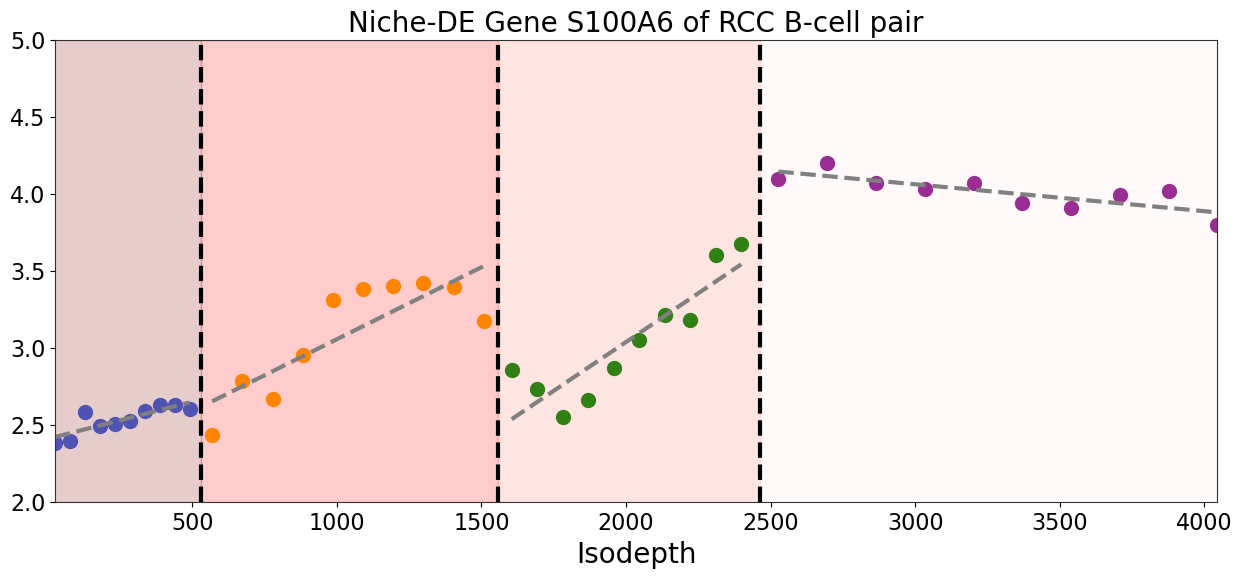

In [25]:
fig,ax=plt.subplots(figsize=[15,6])
spot_colors = ['royalblue', 'orange', 'green', 'purple']
ylim = [2, 5]
for i in range(4):
    if i == 0:
        start = 0
        end = len(output['binned_extra_data'][0][output['binned_labels'] == i])
        x = output['unique_binned_isodepths'][start:end].copy()
        y = output['binned_extra_data'][0][output['binned_labels'] == i].copy()
    else:
        start = start + len(output['binned_extra_data'][0][output['binned_labels'] == i-1])
        end = start + len(output['binned_extra_data'][0][output['binned_labels'] == i])
        #print(start, end)
        x = output['unique_binned_isodepths'][start:end].copy()
        y = output['binned_extra_data'][0][output['binned_labels'] == i].copy()
    #print(x)
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.plot(x, p(x), '--', linewidth=3, color='grey', label=f'Layer {i+1}')
    plt.scatter(x, y, s=100, color=spot_colors[i], alpha=1)
layer_colors=['mistyrose', 'salmon', 'red', 'darkred']
layer_colors = layer_colors[::-1]
#layer_colors= ["#8e0152", "#c51b7d", "#7fbc41", "#1a9641"]
alpha = 0.2
for i in range(4-1):
    if i==0:
        plt.axvline((left_bps[i]+right_bps[i])*0.5, color='black', ls='--', linewidth=3, label=domain_boundary_label)
        ax.fill_betweenx(ylim, 0, (left_bps[i]+right_bps[i])*0.5, color=layer_colors[i], alpha=alpha)
    else:
        plt.axvline((left_bps[i]+right_bps[i])*0.5, color='black', ls='--', linewidth=3)
        ax.fill_betweenx(ylim, (left_bps[i-1]+right_bps[i-1])*0.5, (left_bps[i]+right_bps[i])*0.5, color=layer_colors[i], alpha=alpha)
#plt.legend(fontsize=20)
ax.fill_betweenx(ylim, (left_bps[2]+right_bps[2])*0.5, output['unique_binned_isodepths'][-1], color=layer_colors[3], alpha=alpha)
ax.set_xlim(output['unique_binned_isodepths'][0], output['unique_binned_isodepths'][-1])
ax.set_ylim(ylim)
ax.set_xlabel('Isodepth', fontsize=20)
#ax.set_ylabel('Expression', fontsize=20)
ax.set_title("Niche-DE Gene S100A6 of RCC B-cell pair", fontsize=20)
# text topleft
#ax.text(0.05, 0.95, transform=ax.transAxes, fontsize=20, verticalalignment='top')
ax.tick_params(axis='both', which='major', labelsize=16)
ax.tick_params(axis='both', which='minor', labelsize=14)
#plt.savefig(os.path.join(FIG_PATH, 'kidney_cancer_S100A6_vs_isodepth.pdf'), dpi=300)
plt.show()